In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

## 1. Imports and Model Loading

In [1]:
import os
import uuid
import imageio
import numpy as np
from IPython.display import Image as ImageDisplay

from inference import Inference, ready_gaussian_for_video_rendering, load_image, load_masks, display_image, make_scene, render_video, interactive_visualizer

/home/rxp190007/anaconda3/envs/s4cast_objects/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Warp 1.10.0 initialized:
   CUDA Toolkit 12.8, Driver 12.4
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX 6000 Ada Generation" (47 GiB, sm_89, mempool enabled)
     "cuda:1"   : "NVIDIA RTX 6000 Ada Generation" (47 GiB, sm_89, mempool enabled)
     "cuda:2"   : "NVIDIA RTX 6000 Ada Generation" (47 GiB, sm_89, mempool enabled)
     "cuda:3"   : "NVIDIA RTX 6000 Ada Generation" (47 GiB, sm_89, mempool enabled)
   CUDA peer access:
     Supported fully (all-directional)
   Kernel cache:
     /home/rxp190007/.cache/warp/1.10.0


2025-11-19 23:59:56.095 | INFO     | sam3d_objects.pipeline.inference_pipeline:set_attention_backend:15 - GPU name is NVIDIA RTX 6000 Ada Generation


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2025-11-19 23:59:58.152 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.sparse:__from_env:39 - [SPARSE] Backend: spconv, Attention: sdpa
2025-11-20 00:00:03.887 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.attention:__from_env:30 - [ATTENTION] Using backend: sdpa


[SPARSE][CONV] spconv algo: auto


2025-11-20 00:00:04.623 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2025-11-20 00:00:04.625 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 


In [2]:
PATH = os.getcwd()
TAG = "hf"
config_path = f"{PATH}/../checkpoints/{TAG}/pipeline.yaml"
inference = Inference(config_path, compile=False)

2025-11-20 00:09:33.149 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 


model.pt:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

/home/rxp190007/anaconda3/envs/s4cast_objects/lib/python3.11/site-packages/moge/model/v1.py:171: UserWarning: The following deprecated/invalid arguments are ignored: {'output_mask': True, 'split_head': True}
  warnings.warn(f"The following deprecated/invalid arguments are ignored: {deprecated_kwargs}")
2025-11-20 00:09:51.296 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2025-11-20 00:09:51.299 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:98 - self.device: cuda
2025-11-20 00:09:51.300 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:99 - CUDA_VISIBLE_DEVICES: None
2025-11-20 00:09:51.300 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:100 - Actually using GPU: 0
2025-11-20 00:09:51.301 | INFO     | sam3d_objects.pipeline.inference_pipeline:init_pose_decoder:295 - Using pose decoder: ScaleShiftInvariant
2025-11-20 00:09:51.302 | INFO     | sam3d_obje

## 2. Load input image to lift to 3D (multiple objects)

/home/rxp190007/CODE/Scene4Cast/datasets/preprocess/objects/sam-3d-objects-main/notebook/inference.py:404: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


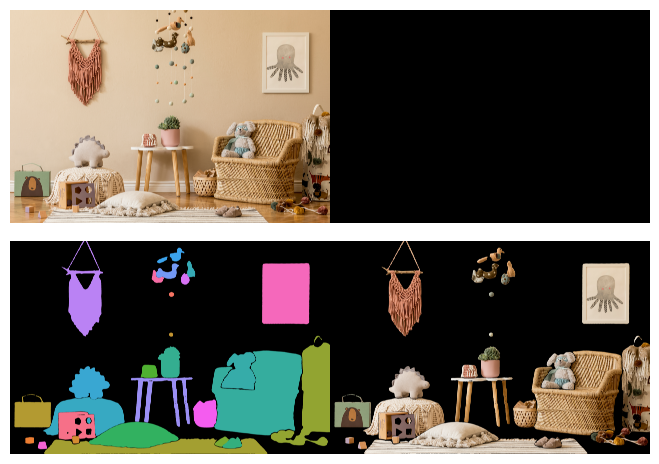

In [3]:
IMAGE_PATH = f"{PATH}/images/shutterstock_stylish_kidsroom_1640806567/image.png"
IMAGE_NAME = os.path.basename(os.path.dirname(IMAGE_PATH))

image = load_image(IMAGE_PATH)
masks = load_masks(os.path.dirname(IMAGE_PATH), extension=".png")
display_image(image, masks)

## 3. Generate Gaussian Splats

In [4]:
outputs = [inference(image, mask, seed=42) for mask in masks]

2025-11-20 00:11:42.439 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:662 - Sampling sparse structure: inference_steps=25, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2025-11-20 00:11:42.440 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:631 - Running condition embedder ...
2025-11-20 00:11:42.578 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:635 - Condition embedder finishes!
2025-11-20 00:11:46.263 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:712 - Downsampled coords from 32584 to 29021
2025-11-20 00:11:46.287 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap:run:368 - Rescaling scale by 1 after downsampling
2025-11-20 00:11:46.288 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:742 - Sampling sparse latent: inference_steps=25, strength=1, interval=[0, 500], rescale_t=1
2025-11-20 00:11:46.289 | INFO     | sam

## 4. Visualize Gaussian Splat of the Scene
### a. Animated Gif

In [5]:
scene_gs = make_scene(*outputs)
scene_gs = ready_gaussian_for_video_rendering(scene_gs)

# export gaussian splatting (as point cloud)
scene_gs.save_ply(f"{PATH}/gaussians/multi/{IMAGE_NAME}.ply")

video = render_video(
    scene_gs,
    r=1,
    fov=60,
    resolution=512,
)["color"]

# save video as gif
imageio.mimsave(
    os.path.join(f"{PATH}/gaussians/multi/{IMAGE_NAME}.gif"),
    video,
    format="GIF",
    duration=1000 / 30,  # default assuming 30fps from the input MP4
    loop=0,  # 0 means loop indefinitely
)

# notebook display
ImageDisplay(url=f"gaussians/multi/{IMAGE_NAME}.gif?cache_invalidator={uuid.uuid4()}",)

Rendering: 300it [00:30,  9.99it/s]


### b. Interactive Visualizer

In [6]:
# might take a while to load (black screen)
interactive_visualizer(f"{PATH}/gaussians/multi/{IMAGE_NAME}.ply")

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://43b98df75b3e4d0156.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
